--- PUNTOS 1, 2, 4 y 5: Comparativa de Filtros (Pasa-bajos y Pasa-altos) ---


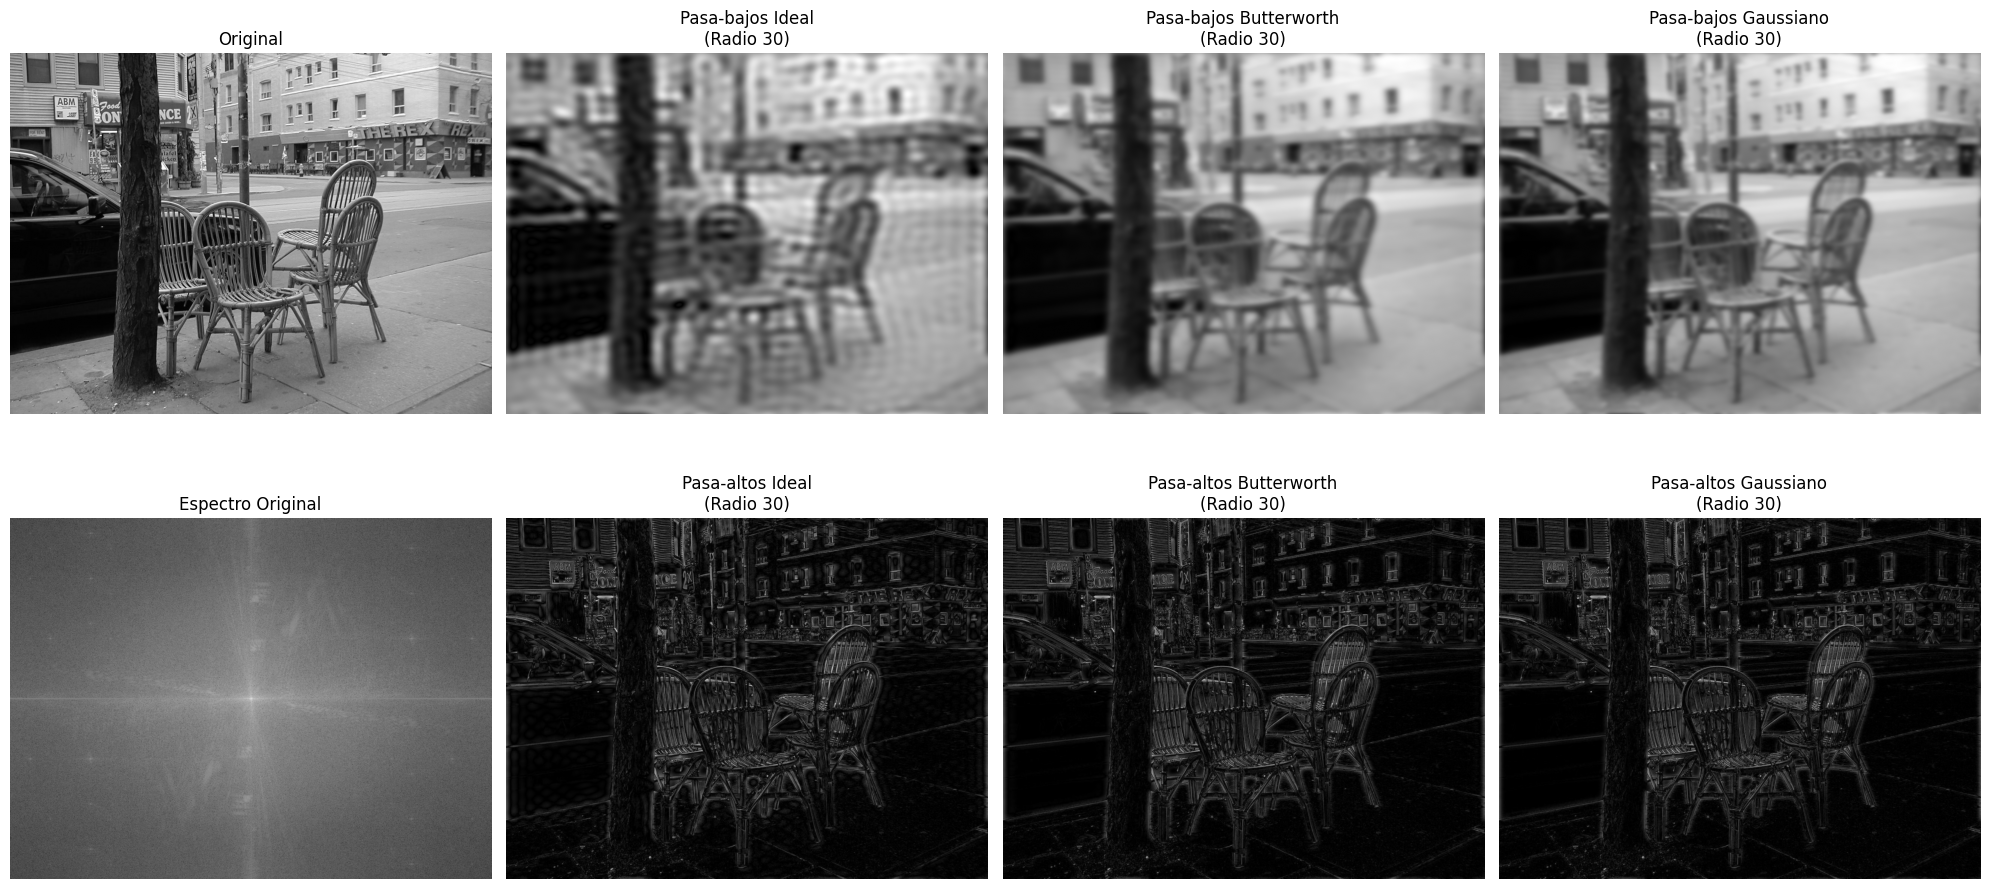

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def crear_filtro_frecuencial(shape, radio, tipo='ideal', pasa_altos=False, n=2):
    """Genera filtros Ideal, Butterworth o Gaussiano directamente en frecuencia."""
    filas, columnas = shape
    centro_x, centro_y = filas // 2, columnas // 2
    
    # Crear una grilla de coordenadas
    x, y = np.ogrid[:filas, :columnas]
    # Calcular la distancia D(u,v) desde el centro
    distancia = np.sqrt((x - centro_x)**2 + (y - centro_y)**2)
    
    # Iniciar filtro base
    H = np.zeros((filas, columnas), dtype=np.float32)
    
    if tipo == 'ideal':
        H[distancia <= radio] = 1
    elif tipo == 'butterworth':
        # 1 / (1 + (D / D0)^(2n))
        H = 1 / (1 + (distancia / radio)**(2 * n))
    elif tipo == 'gaussiano':
        # exp(-D^2 / 2*(D0^2))
        H = np.exp(-(distancia**2) / (2 * (radio**2)))
        
    # Si es pasa-altos, invertimos el filtro (H_hp = 1 - H_lp)
    if pasa_altos:
        H = 1 - H
        
    return H

def aplicar_y_mostrar_filtro(img_path, radio=30):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"⚠️ Error: No se encontró la imagen '{img_path}'.")
        return
        
    # 1. Calcular TDF y centrar
    fshift = np.fft.fftshift(np.fft.fft2(img))
    
    tipos = ['ideal', 'butterworth', 'gaussiano']
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))
    
    # Referencia Original
    axs[0, 0].imshow(img, cmap='gray'); axs[0, 0].set_title('Original'); axs[0, 0].axis('off')
    axs[1, 0].imshow(np.log(np.abs(fshift)+1), cmap='gray'); axs[1, 0].set_title('Espectro Original'); axs[1, 0].axis('off')
    
    for i, tipo in enumerate(tipos):
        # Generar filtro PASA-BAJOS
        H_pb = crear_filtro_frecuencial(img.shape, radio, tipo=tipo, pasa_altos=False)
        # Aplicar filtro multiplicando elemento a elemento
        fshift_filtrado = fshift * H_pb
        # TDF Inversa
        img_pb = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_filtrado)))
        
        axs[0, i+1].imshow(img_pb, cmap='gray')
        axs[0, i+1].set_title(f'Pasa-bajos {tipo.capitalize()}\n(Radio {radio})')
        axs[0, i+1].axis('off')
        
        # Generar filtro PASA-ALTOS
        H_pa = crear_filtro_frecuencial(img.shape, radio, tipo=tipo, pasa_altos=True)
        fshift_filtrado_pa = fshift * H_pa
        img_pa = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_filtrado_pa)))
        
        axs[1, i+1].imshow(img_pa, cmap='gray')
        axs[1, i+1].set_title(f'Pasa-altos {tipo.capitalize()}\n(Radio {radio})')
        axs[1, i+1].axis('off')

    plt.tight_layout()
    plt.show()

print("--- PUNTOS 1, 2, 4 y 5: Comparativa de Filtros (Pasa-bajos y Pasa-altos) ---")
# Usamos 'chairs.jpg' u otra que tengas a mano. 
# Podés probar cambiando el radio a 10 (efecto extremo) o a 80 (efecto sutil).
aplicar_y_mostrar_filtro('chairs.jpg', radio=30)

--- PUNTO 3: Filtro Gaussiano (De Espacial a Frecuencial) ---


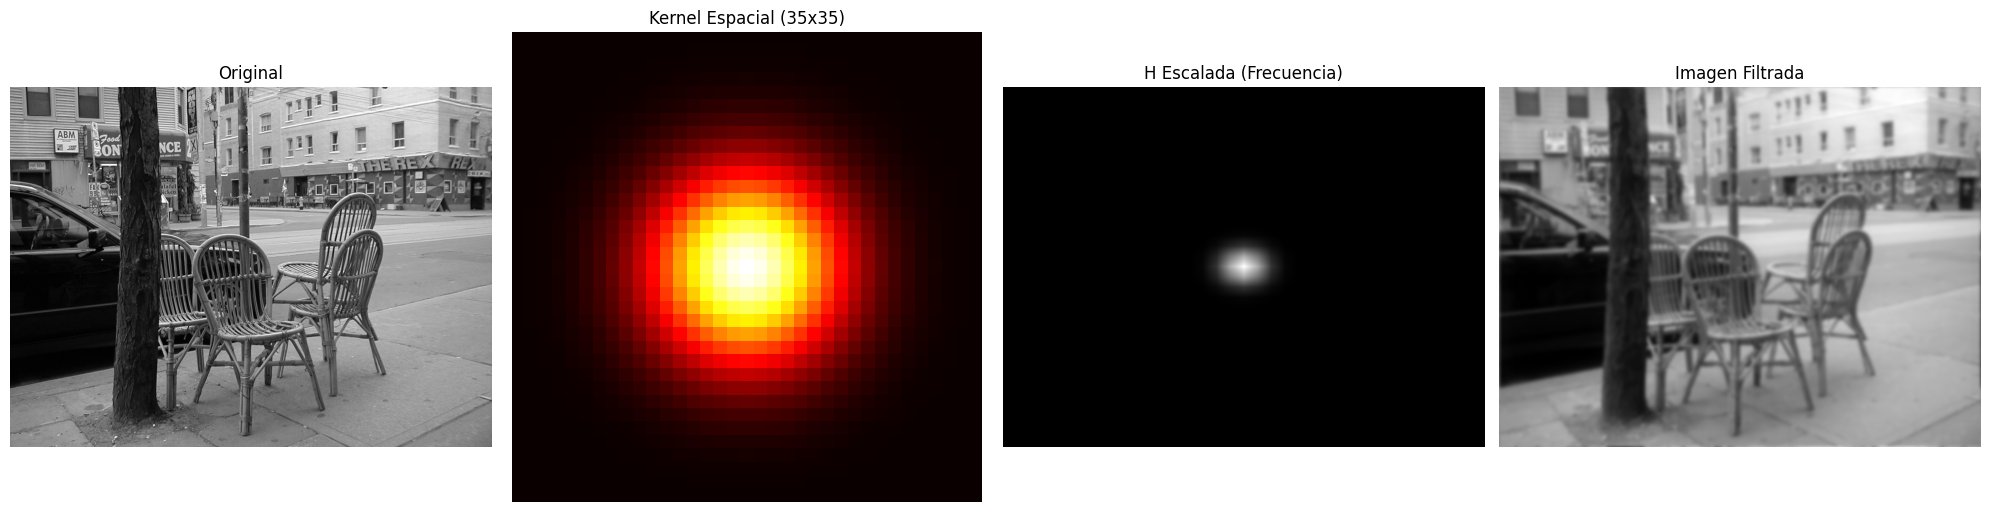

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("--- PUNTO 3: Filtro Gaussiano (De Espacial a Frecuencial) ---")

img = cv2.imread('chairs.jpg', cv2.IMREAD_GRAYSCALE)

if img is not None:
    # 1. Definir kernel Gaussiano espacial (35x35)
    # GetGaussianKernel devuelve un array 1D, lo multiplicamos por su transpuesta para hacer el 2D
    k_1d = cv2.getGaussianKernel(35, sigma=5)
    kernel_espacial_35x35 = k_1d @ k_1d.T
    
    # 2. Obtener su respuesta en frecuencia (TDF del kernel chiquito)
    fft_kernel_chico = np.fft.fft2(kernel_espacial_35x35)
    fft_kernel_chico_shift = np.fft.fftshift(fft_kernel_chico)
    
    # 3. Escalar (resize) la magnitud del filtro frecuencial al tamaño de la imagen original
    # Usamos np.abs para quedarnos solo con la respuesta de amplitud
    H_escalado = cv2.resize(np.abs(fft_kernel_chico_shift), (img.shape[1], img.shape[0]))
    
    # Para que actúe como un filtro correcto (ganancia max 1), lo normalizamos
    H_escalado = H_escalado / np.max(H_escalado)
    
    # 4. Calcular la TDF de la imagen
    fshift_img = np.fft.fftshift(np.fft.fft2(img))
    
    # 5. Producto de transformadas (Filtrado)
    fshift_filtrado = fshift_img * H_escalado
    
    # 6. Transformada Inversa para recuperar la imagen
    img_filtrada = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_filtrado)))
    
    # Visualización
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    axs[0].imshow(img, cmap='gray'); axs[0].set_title('Original'); axs[0].axis('off')
    axs[1].imshow(kernel_espacial_35x35, cmap='hot'); axs[1].set_title('Kernel Espacial (35x35)'); axs[1].axis('off')
    axs[2].imshow(H_escalado, cmap='gray'); axs[2].set_title('H Escalada (Frecuencia)'); axs[2].axis('off')
    axs[3].imshow(img_filtrada, cmap='gray'); axs[3].set_title('Imagen Filtrada'); axs[3].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Error: No se encontró 'chairs.jpg'.")

### Conclusiones del Ejercicio 3: Filtros Pasa-bajos y Pasa-altos

**1. Filtro Pasa-bajos Ideal (Corte abrupto)**
* **Efecto:** Difumina la imagen al eliminar las altas frecuencias (bordes). 
* **Fenómeno de Gibbs:** Al tener un corte drástico (un cilindro perfecto en el espectro), genera ondas o un efecto de anillado (*ringing*) muy notorio alrededor de los bordes de los objetos en la imagen reconstruida. A menor radio de corte, mayor es el desenfoque y más severo el anillado.

**2. Filtro Pasa-bajos Butterworth (Transición suave)**
* **Efecto:** También difumina, pero introduce una transición suave dictada por el orden del filtro ($n$).
* **Fenómeno de Gibbs:** Se reduce drásticamente. En órdenes bajos (ej. $n=2$), el ringing es casi imperceptible, logrando un desenfoque mucho más natural que el filtro Ideal.

**3 y 4. Filtro Gaussiano (Espacial vs. Frecuencial)**
* **Efecto:** Produce el desenfoque más suave posible. La Transformada de Fourier de una campana de Gauss espacial es otra campana de Gauss en frecuencia.
* **Fenómeno de Gibbs:** Inexistente. Al no tener discontinuidades, no produce ningún tipo de anillado.
* **Espacial vs. Frecuencial (Comparativa):** Definir el filtro en el dominio espacial (35x35), calcular su TDF y escalarlo (`cv.resize`) funciona, pero la interpolación matemática al agrandar la matriz puede introducir ruidos o artefactos sutiles. Diseñar el filtro Gaussiano **directamente en el dominio de la frecuencia** (evaluando la ecuación en la grilla del tamaño exacto de la imagen) es más eficiente, computacionalmente más rápido y matemáticamente exacto.

**5. Filtros Pasa-altos**
* **Comportamiento:** Son el complemento matemático de los pasa-bajos ($H_{PA} = 1 - H_{PB}$). En lugar de difuminar, eliminan las zonas de color liso (bajas frecuencias) y resaltan únicamente los bordes y texturas finas.
* **Diferencias:** El Pasa-altos Ideal genera bordes con eco (ringing). El Gaussiano extrae los bordes de manera limpia y sin artefactos secundarios.